![TU Delft logo](images/tu_logo.png) 
# Homework series 2 for Data Assimilation course (WI4475 2026)

This is the second homework series for the data assimilation course (WI4475 2026). There are 2 questions with 5 subquestions each. For each of these 10 subquestions you can earn one point, which directly sums to the grade for this homework series. The code in this documents works with Jupyter with a Julia kernel. With that set-up you can just add the answers after each question and generate a pdf from the notebook when you are done.

Please submit your completed homework series as a single pdf file via Brightspace before de deadline given there.

The files for this homework series are all available [here](https://github.com/robot144/wi4475_2026). 

Good luck and feel free to reach out if you have any questions!

Martin

---
## Julia and Jupyter

This homework was created using Jupyter with a Julia kernel. Jupyter is a notebook system where one can combine text and code into one document that contains a list of cells. Each cell can contain code or text. Unlike the commonly used  Python language, Julia is a language that was designed from the start to be fast. It can be used for numerical computing in a way that is very similar to python in the computation cells, once the Julia kernel is installed. 
Intallation instructions for Julia with Jupyter can be found [in the README.md](https://github.com/robot144/wi4475_2026)


    
---


In [ ]:
# Install some packages if you don't have them yet
# This will take a while the first time you run it (especially 
# the DifferentialEquations package).

using Pkg
packages=["Plots", "LaTeXStrings", "Latexify", "DifferentialEquations","Symbolics","Zygote","SciMLSensitivity","ComponentArrays"]
Pkg.add(packages)
for p in packages
    #Pkg.add(p)
    println("using $p")
    @eval using $(Symbol(p))
end

# Purpose of each package:
# Plots: for plotting results
# LaTeXStrings: for using LaTeX in plot labels
# Latexify: for converting Julia expressions to LaTeX
# DifferentialEquations: for solving ODEs
# Symbolics: for symbolic differentiation
# Zygote: for automatic differentiation (used in adjoint sensitivity analysis)
# SciMLSensitivity: for adjoint sensitivity analysis of ODEs (needed to combine Zygotewith DifferentialEquations)
# ComponentArrays: Combine multiple vectors into a large vector, but also keep a clear structure

---
## Question 1: Gradient computation for a general discrete time or continuous time system

In the first question we will derive the gradient of a cost function for a general discrete time system and a general continuous time system. We will do this in multiple ways.

Assume we have a discrete time system of the form:
$$\mathbf{x}_{k+1} = \mathbf{M}(\mathbf{x}_k, \mathbf{u}_k)$$
where $\mathbf{x}_k \in \mathbb{R}^n$ is the state at time step $k$, $\mathbf{u}_k \in \mathbb{R}^m$ is the control input at time step $k$. The initial state $\mathbf{x}_0$ is given by:
$$\mathbf{x}_0 = \mathbf{c}_0$$

We also have a cost function based on measurements at the final time step of the form:
$$J = (\mathbf{z}_N - H \mathbf{x}_N)^T R^{-1} (\mathbf{z}_N - H \mathbf{x}_N)$$
where $\mathbf{z}_N \in \mathbb{R}^p$ is the observation at the final time step, $H \in \mathbb{R}^{p \times n}$ is the observation operator, and $R \in \mathbb{R}^{p \times p}$ is the observation error covariance matrix.

The aim is to estimate $\mathbf{c}_0$ by minimizing the cost function $J$. To do this we need to compute the gradient of $J$ with respect to $\mathbf{c}_0$.

---
### 1a: 

Use the forward method to derive the gradient of $J$ with respect to $\mathbf{c}_0$. This means that you will need to compute $\frac{\partial \mathbf{x}_1}{\partial \mathbf{c}_0}$, then $\frac{\partial \mathbf{x}_2}{\partial \mathbf{c}_0}$, and so on for all $k$ until $k=N$ and then use the chain rule to obtain $\frac{\partial J}{\partial \mathbf{c}_0}$.
For notation, please use $\mathbf{M}_{x_k}$ to denote the Jacobian of $\mathbf{M}$ with respect to $\mathbf{x}_k$, and $\mathbf{M}_{u_k}$ to denote the Jacobian of $\mathbf{M}$ with respect to $\mathbf{u}_k$.

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 1b:

Next, we compute the same gradient but now using Lagrange multipliers. This means that we will need to write down the Lagrangian for this problem, then compute the gradient of the Lagrangian with respect to $\mathbf{c}_0$.

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 1c: 

Discuss which of the two methods (forward or backward) is more efficient for computing the gradient in this case and why. You can assume that the state dimension is $n$, the control dimension is $m$, and that storage of the Jacobians is not an issue. Finally assume that you can run multiple computations in parallel if needed; does this change your answer?


__Answer__

Your answer goes $h\epsilon r \epsilon$

---
## Continuous time system

Next, we move to the continuous time system. Assume we have a continuous time system of the form:
$$\frac{d \mathbf{x}}{d t} = \mathbf{M}(\mathbf{x}(t), \mathbf{u}(t))$$
where $\mathbf{x}(t)$ is the state at time $t$, $\mathbf{u}(t)$ is the control input at time $t$. The initial state $\mathbf{x}(0)$ is given by:
$$\mathbf{x}(0) = \mathbf{c}_0$$
We also have a cost function based on measurements at the final time $T$ of the form:
$$J = (\mathbf{z}(T) - H \mathbf{x}(T))^T R^{-1} (\mathbf{z}(T) - H \mathbf{x}(T))$$
where $\mathbf{z}(T)$ is the observation at the final time, $H$ is the observation operator, and $R$ is the observation error covariance matrix.


---
### 1d:

Derive the equations of the adjoint model and the gradient of $J$ with respect to $\mathbf{c}_0$ using the adjoint method, i.e.
by introducing the adjoint variable $\boldsymbol{\lambda}(t)$ extending the cost function. The Jacobians are defined as $\mathbf{M}_{x(t)}$ and $\mathbf{M}_{u(t)}$ similar to before.

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### Parameter estimation using state augmentation

Finally we will add a vector of parameters $\mathbf{\theta}$ to the system and try to estimate these parameters using the same cost function as before. The system is now given by:
$$\frac{d \mathbf{x}}{d t} = \mathbf{M}(\mathbf{x}(t), \mathbf{u}(t), \mathbf{\theta})$$
$$\mathbf{x}(0) = \mathbf{c}_0$$
where $\mathbf{\theta}$ is the vector of parameters that we want to estimate, and $\mathbf{c}_0$ is no longer uncertain, but fixed. The cost function is the same as before:
$$J = (\mathbf{z}(T) - H \mathbf{x}(T))^T R^{-1} (\mathbf{z}(T) - H \mathbf{x}(T))$$


---
### 1e:

The gradient of $J$ with respect to $\mathbf{\theta}$ can be computed using the same adjoint method as before, but in this exercise we'll use a different method. We will use the method of state augmentation, where we augment the state vector with the parameters $\mathbf{\theta}$ and then derive the adjoint equations for this augmented system.

Let's define the augmented state vector as $\tilde{\mathbf{x}}(t) = [\mathbf{x}(t); \mathbf{\theta}]$, where we stack the state and the parameters together. The dynamics of the augmented system can be written as:
$$\frac{d \tilde{\mathbf{x}}}{d t} = \tilde{\mathbf{M}}(\tilde{\mathbf{x}}(t), \mathbf{u}(t))$$
where $\tilde{\mathbf{M}}$ is the augmented dynamics that includes both the original dynamics and the fact that the parameters are constant in time, i.e. $\frac{d \mathbf{\theta}}{d t} = 0.0$.

Steps:
1. Write down the augmented dynamics $\tilde{\mathbf{M}}$ explicitly.
2. Write down the cost function $J$ in terms of the augmented state vector $\tilde{\mathbf{x}}(t)$.
3. Write down the solution for the adjoint and the gradient using the answer from 1d, but now for the augmented system.
4. Expand the equations to their full form and extract the gradient with respect to $\mathbf{\theta}$.

Notes:
- the gradient of the cost function will now be with respect to the augmented state vector, and we can extract the gradient with respect to $\mathbf{\theta}$ from that.
- derivatives with respect to $\mathbf{\theta}$ will appear, i.e. $\mathbf{M}_{\theta}=\frac{\partial \mathbf{M}}{\partial \mathbf{\theta}}$
- If you don't have an answer for 1d, you can still try to do this exercise by using the general form of the adjoint equations from the slides or book.
 

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
## Exercise 2: Automatic diffferentiation for a wild-fire model

Consider a simple model for the spread of a wild-fire in one dimension, given by the following PDE:
__heat equation with reaction term__

$$\frac{\partial T}{\partial t} = D \frac{\partial^2 T}{\partial x^2} + \frac{Q R(F, T)}{h \rho c_p}$$
$$R(F,T) = k F e^{-T_c/T}$$
where $T(x,t)$ is the temperature at position $x$ and time $t$, $D$ is the thermal diffusivity, $Q$ is the heat release rate per unit fuel mass, $F$ is the fuel load per unit area, $T_c$ is the characteristic activation temperature, $k$ is the reaction rate constant, $h$ is the characteristic height of the heated layer, $\rho$ is air density, and $c_p$ is the specific heat capacity.

__fuel concentration equation__

As the fire burns, the fuel is consumed according to the reaction term, which can be modeled as:
$$\frac{\partial F}{\partial t} = -R(F, T)$$


The default parameters for this model are:
- $h = 20.0 \, [\text{m}]$ (characteristic height of heated layer)
- $\rho = 1.2 \, [\text{kg/m}^3]$ (air density at ambient conditions)
- $c_p = 1000.0 \, [\text{J/(kg K)}]$ (specific heat capacity of air)
- $D = 0.5 \, [\text{m}^2/\text{s}]$ (turbulent thermal diffusivity in wildfire conditions)
- $Q = 1.8 \times 10^7 \, [\text{J/kg}]$ (heat release rate for wood combustion, ~18 MJ/kg)
- $T_c = 4000.0 \, [\text{K}]$ (characteristic activation temperature)
- $k = 0.05 \, [\text{s}^{-1}]$ (reaction rate constant)
- $F_0 = 1.0 \, [\text{kg/m}^2]$ (initial fuel load per unit area, typical for forest floor)
- Ambient temperature: $T_{\text{ambient}} = 300 \, [\text{K}]$ (~27°C)
- Ignition temperature: $T_{\text{ignition}} \approx 600 \, [\text{K}]$ (~327°C)

We can simplify the model slighty by defining $\beta = \frac{Q}{h \rho c_p}$. This gives us the following system of PDEs:
$$\frac{\partial T}{\partial t} = D \frac{\partial^2 T}{\partial x^2} + \beta R(F, T)$$
$$\frac{\partial F}{\partial t} = -R(F, T)$$

To find a numerical  solution to this system, we discretize on a spatial grid $x=[0.0,\Delta x, 2\Delta x, \dots, L]$ and solve the resulting system of ODEs, using a central finite difference for the spatial derivative and keep the time integration continuous for now.
$$\frac{\partial T_m}{\partial t} = D \frac{T_{m+1} - 2T_m + T_{m-1}}{\Delta x^2} + \beta R(F_m, T_m)$$
$$\frac{\partial F_m}{\partial t} = -R(F_m, T_m)$$
$$R(F,T) = k F e^{-T_c/T}$$



In [ ]:
# check β
ρ = 1.2 # kg/m^3
Q = 1.8e7 # J/kg
h = 20.0 # m
c_p = 1000.0 # J/(kg K)
β = Q / (h * ρ * c_p)
@show β

In [ ]:
# Define the wild fire model as a system of ODEs

function wild_fire(du_dt, u, p, t)
    D,β,k,T_c,Δx=p #unpack parameters
    T=u.T # extract temperature profile
    F=u.F # extract fuel profile
    n=length(T) # number of spatial points
    # compute reaction term
    R=k.*F.*exp.(-T_c./T)
    # compute spatial second derivative using central finite difference
    ∂²T=similar(T)
    #left boundary (periodic)
    ∂²T[1]=(T[2]-2T[1]+T[end])/Δx^2
    #right boundary (periodic)
    ∂²T[end]=(T[1]-2T[end]+T[end-1])/Δx^2
    #interior points
    for i in 2:n-1
        ∂²T[i]=(T[i+1]-2T[i]+T[i-1])/Δx^2
    end
    # compute time derivatives
    du_dt.T=D.*∂²T.+β.*R
    du_dt.F=-R
end

In [ ]:
# parameters
D = 0.5                      # turbulent thermal diffusivity in wildfire conditions
β = 750.0                    # heat release parameter
k = 0.05                     # reaction rate constant
T_c = 4000.0                 # ignition temperature
L = 1000.0                   # length of the spatial domain
F_i = 1.0                    # initial fuel concentration
T_a = 300.0                  # ambient temperature
T_i = 1200.0                 # ignition temperature
n = 100                      # number of spatial points
Δx = L/n                     # spatial step size
x_grid = Δx/2:Δx:L-Δx/2      # spatial grid
# initial conditions
function bump(x,T_0,T_i,x_middle,x_width) #gaussian bump function
    return T_0+(T_i-T_0)*exp(-0.5*((x-x_middle)/x_width)^2)
end
T0 = bump.(x_grid,T_a,T_i,L/2,L/20.0) # initial temperature profile
F0 = F_i * ones(n) # initial fuel concentration
u0 = ComponentArray(T=T0, F=F0) # initial state vector
p = [D,β,k,T_c,Δx] # pack parameters into a vector
tspan = (0.0, 5*3600.0) # time span for the simulation (in seconds)

prob = ODEProblem(wild_fire, u0, tspan, p)
sol = solve(prob, Tsit5())

nothing #no output

[ Info: Saved animation to /home/verlaan/deepblack/src/wi4475_prep.git/tmp.gif


Plots.AnimatedGif("/home/verlaan/deepblack/src/wi4475_prep.git/tmp.gif")
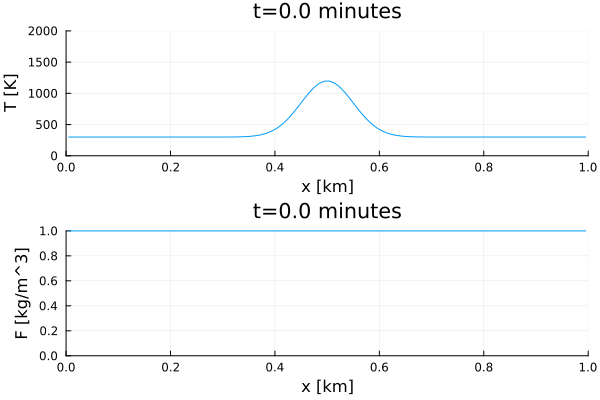

In [5]:
# plot animation of the solution

#plotting a single time profile of h
function plot_profile(u,t, p, x_grid)
    D,β,k,T_c,Δx=p #unpack parameters
    T=u.T # extract temperature profile
    F=u.F # extract fuel profile
    n=length(T) # number of spatial points

    panel1=plot(x_grid/1000, T, title="t=$(t/60.0) minutes",label=false,xlims=(0,L/1000),ylims=(0.0,2000.0))
    xlabel!("x [km]")
    ylabel!("T [K]")
    panel2=plot(x_grid/1000, F, title="t=$(t/60.0) minutes",label=false,xlims=(0,L/1000),ylims=(0.0,1.0))
    xlabel!("x [km]")
    ylabel!("F [kg/m^3]")
    plot(panel1, panel2, layout=(2,1))
end

function animate_profile(sol, p, x_grid, timestep=60.0, fps=20)
    # create an animation
    times = sol.t[1]:timestep:sol.t[end] # times at which to plot the solution
    nt = length(times)
    anim = @animate for i in 1:nt
            u=sol(times[i])
            plot_profile(u, times[i], p, x_grid)
    end
    return gif(anim, fps = fps)
end

animate_profile(sol, p, x_grid)

---
## 2a

To get a better understanding of the equations, let's first simplify the problem by considering only a single spatial point, i.e. we ignore the spatial derivative and just look at the reaction term. This gives us the following system of ODEs:
$$\frac{d T}{d t} = \beta R(F, T)$$
$$\frac{d F}{d t} = -R(F, T)$$
$$R(F,T) = k F e^{-T_c/T}$$

Show that the change in temperature can be expressed as a function of the change in fuel load, i.e. derive an expression for 
$$T(t) = T_0 + \Delta T(t) = g(F(t))$$
Assume that after some time all the fuel is consumed, i.e. $F(t) \to 0$ as $t \to \infty$, and that the initial temperature is equal to the ignition temperature, i.e. $T(0) = T_{\text{ignition}}=T_i$.

Implement this function $g(F)$ and compute the derivative of $\lim_{t \to \infty} T(t)$ with respect to $F(0)=F_0$ using symbolic differentiation. You can use the `Symbolics` package for this, as shown in the code snippet below.

__Answer__

Your answer goes $h\epsilon r \epsilon$

In [6]:
# This code snippet shows how to use Symbolics.jl to compute the derivative of a function g with respect to ΔF.
function g(ΔF)
    return sin(ΔF) # TODO: replace with actual function
end

@variables ΔF
g_s=g(ΔF) # create symbolic expression for g
display(g_s)

dT_dF=Symbolics.derivative(g_s, ΔF)
display(dT_dF)

sin(ΔF)

cos(ΔF)

---
### 2b

Implement the function $\mathbf{M}(\mathbf{x})$ of the dynamical system of question 2a, where $\mathbf{x} = [T, F]^T$.
Use symbolic differentiation to compute the Jacobian of $\mathbf{M}$ with respect to $\mathbf{x}$, i.e. compute $\mathbf{M}_x = \frac{\partial \mathbf{M}}{\partial \mathbf{x}}$. 

Note: We're implementing multiple models in this notebook and all variables are defined in the global scope, so make sure to use different variable names for the different models to avoid confusion.

__Answer__

Your answer goes $h\epsilon r \epsilon$

In [8]:
# Example to help with syntax for symbolic differentiation of a function of multiple variables
@variables yₛ  zₛ

function f_test(u) 
    y=u[1]
    z=u[2]
    return [z^2 + y, sin(z*y)]
end
f_s = f_test([yₛ,zₛ]) # create a symolic representation of the function f.
display(f_s)

df_dx = Symbolics.jacobian(f_s, [yₛ,zₛ])
display(df_dx)

# show the formula as latex for later use
show(latexify(df_dx))

nothing

2-element Vector{Num}:
  yₛ + zₛ^2
 sin(yₛ*zₛ)

2×2 Matrix{Num}:
             1            2zₛ
 cos(yₛ*zₛ)*zₛ  yₛ*cos(yₛ*zₛ)

L"\begin{equation}
\left[
\begin{array}{cc}
1 & 2 \mathtt{z{_s}} \\
\cos\left( \mathtt{y{_s}} \mathtt{z{_s}} \right) \mathtt{z{_s}} & \mathtt{y{_s}} \cos\left( \mathtt{y{_s}} \mathtt{z{_s}} \right) \\
\end{array}
\right]
\end{equation}
"

---
### 2c

Let's continue on question 2b and implement a few time-steps with Euler-forward to see how symbolic differentiation works out there. Study the expression for one, two and three time-steps of Euler forward. Let $\mathbf{x}_k$ denote the state at time step $k$, starting from the initial condition $\mathbf{x}_0$. Express $\mathbf{x}_1$ in terms of $\mathbf{x}_0$, $\mathbf{M}_{x_0}$ and the time step $\Delta t$. Next, express $\mathbf{x}_2$ in terms of $\mathbf{x}_0$, $\mathbf{M}_{x_0}$, $\mathbf{M}_{x_1}$ and $\Delta t$. Why is symbolic differentiation not very efficient for this?

__Answer__

Your answer goes $h\epsilon r \epsilon$

In [10]:
# Code snippet to help with question 2c
@variables Δtₛ
function M_point_euler(x,Δt)
    return x + Δt*M_point(x) # one time step of Euler forward
end
x_1_s = M_point_euler([T_s,F_s],Δtₛ) # symbolic version of one time step of Euler forward
display(x_1_s)


2-element Vector{Num}:
 T_s + 37.5F_s*exp(-4000.0 / T_s)*Δtₛ
 F_s - 0.05F_s*exp(-4000.0 / T_s)*Δtₛ

---
### 2d Use adjoint ODE to compute sensitivity

A method that does work is to compute the gradient with the adjoint approach. To get an impression for this example, derive the equations to compute the derivative of the final temperature with respect to the initial fuel load. Write the equations in terms of $T$, $F$ and their adjoint variables $\lambda_T$ and $\Lambda_F$. You should get a set of two forward ODE's (one for each variable), two adjoint ODE's, initial and/or final conditions and a formula for the gradient.

Notes:
- This question is about finding the equations to solve. You don't have to try to solve them neither analytically nor numerically.
- You can reuse the answer of 2b, if you want.

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 2e Reverse mode automatic differentiation

Autodiff, especially reverse mode autodiff, is a powerful tool for computing gradients of functions that are implemented as computer programs. Here we will use the Zygote reverse mode automatic differentiation package to compute the gradient of a cost function with respect to the initial conditions of our wildfire model.
To show just how powerful, we'll use the **full PDE version** of the model shown at the start of exercise 2. More specifically, we will compute the derivative of the final temperature at the center of the domain with respect to the initial fuel load, i.e. $\frac{\partial T_{\text{final}}(x_{\text{middle}})}{\partial F_{i}}$.

Check you answer with finite differences for $F_i$.

__Answer__

Your answer goes $h\epsilon r \epsilon$

In [26]:
# Code snippet to show  how to use Zygote tom compute a gradient
function loss(T,T_m) #Tm is the measurement, T is the model prediction
    return (T - T_m)^2
end

# First wrap the function so it only takes T as input and only returns the loss
# This is often necessary to use autodiff tools to make explicit what the input and output variables are.
# Other packages may have other methods to specify this. In this simple example, it's not strictly necessary.
function loss_T(T)
    T_m = 1000.0 # measurement
    return loss(T, T_m)
end

dloss_dT = Zygote.gradient(loss_T, 900.0) # compute the gradient of the loss with respect to T at T=900K
@show dloss_dT
#use dloss_dT[1] to get the actual value of the gradient since Zygote returns a tuple
@show dloss_dT[1] 


dloss_dT = (-200.0,)
dloss_dT[1] = -200.0


-200.0